In [23]:
import os
import shutil
import subprocess
import tempfile
from functools import lru_cache
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FORCE_TEX = True
BASE_FONT_SIZE = 24
AXIS_LABEL_SIZE = 30
AXIS_TITLE_SIZE = 26
TICK_LABEL_SIZE = 24
LEGEND_FONT_SIZE = 22
VALUE_LABEL_FONT_SIZE = 22
DEFAULT_FIGSIZE = (11.2, 6.8)

ORDER = ["Safe", "Unknown", "Unsafe"]
SERIES_ORDER = [r"$\alpha\beta$-CROWN", "CSI (Object)", "CSI (Background)"]
SERIES_STYLE = {
    r"$\alpha\beta$-CROWN": {"color": "#4C72B0", "hatch": ""},
    "CSI (Object)": {"color": "#55A868", "hatch": "//"},
    "CSI (Background)": {"color": "#C44E52", "hatch": "\\\\"},
}

def map_result_to_outcome(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value.startswith("unsat"):
        return "Safe"
    if value.startswith("timeout"):
        return "Unknown"
    if value.startswith("sat"):
        return "Unsafe"
    return "Other"

def normalize_tag(value):
    value = str(value).strip().lower()
    return value.replace("fixnonmask", "fix_nonmask").replace("fixmask", "fix_mask")

@lru_cache(maxsize=1)
def latex_ready():
    required_commands = ("latex", "dvipng")
    if any(shutil.which(command) is None for command in required_commands):
        return False

    if shutil.which("kpsewhich") is not None:
        latex_fmt = subprocess.run(
            ["kpsewhich", "latex.fmt"],
            capture_output=True,
            text=True,
            check=False,
        )
        if latex_fmt.returncode != 0 or not latex_fmt.stdout.strip():
            return False

    latex_source = "\n".join([
        r"\documentclass{article}",
        r"\begin{document}",
        r"lp",
        r"\end{document}",
    ])

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_path = Path(tmpdir) / "matplotlib_tex_probe.tex"
        tex_path.write_text(latex_source, encoding="utf-8")
        result = subprocess.run(
            ["latex", "-interaction=nonstopmode", "--halt-on-error", tex_path.name],
            cwd=tmpdir,
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and (Path(tmpdir) / "matplotlib_tex_probe.dvi").exists()

def has_tex_package(package_name):
    if shutil.which("kpsewhich") is None:
        return False
    return subprocess.run(
        ["kpsewhich", f"{package_name}.sty"],
        capture_output=True,
        text=True,
        check=False,
    ).returncode == 0

def configure_plot_style(force_tex=FORCE_TEX):
    use_tex = force_tex and latex_ready()
    preamble = r"\usepackage{fontawesome5}" if use_tex and has_tex_package("fontawesome5") else ""

    if force_tex and not use_tex:
        print("LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.")

    mpl.rcParams.update({
        "text.usetex": use_tex,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "text.latex.preamble": preamble,
        "font.size": BASE_FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": AXIS_TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    return use_tex

def load_outcome_counts(csv_path, k_value):
    df = pd.read_csv(csv_path).copy()
    df["tag_norm"] = df["tag"].apply(normalize_tag)
    df["k"] = pd.to_numeric(df["k"], errors="coerce")
    if "is_global" in df.columns:
        df["is_global"] = pd.to_numeric(df["is_global"], errors="coerce").fillna(0)
    else:
        df["is_global"] = 0
    df["outcome"] = df["result"].apply(map_result_to_outcome)

    df = df[(df["k"] == k_value) & df["outcome"].isin(ORDER)].copy()

    grouped = {
        r"$\alpha\beta$-CROWN": df[(df["tag_norm"] == "global") | (df["is_global"] == 1)],
        "CSI (Object)": df[df["tag_norm"] == "fix_nonmask"],
        "CSI (Background)": df[df["tag_norm"] == "fix_mask"],
    }

    counts = {
        label: group["outcome"].value_counts().reindex(ORDER, fill_value=0)
        for label, group in grouped.items()
    }

    summary = pd.DataFrame({label: counts[label] for label in SERIES_ORDER}, index=ORDER)
    return summary

def plot_outcome_counts(csv_path, k_value, output_path, dataset_label, figsize=DEFAULT_FIGSIZE):
    configure_plot_style()
    summary = load_outcome_counts(csv_path, k_value)

    print(f"{dataset_label} (k={k_value})")
    print(summary)

    x = np.arange(len(ORDER))
    width = 0.22
    offsets = width * np.array([-1, 0, 1])
    ymax = max(int(summary.to_numpy().max()), 1)

    fig, ax = plt.subplots(figsize=figsize)
    containers = []

    for offset, label in zip(offsets, SERIES_ORDER):
        style = SERIES_STYLE[label]
        bars = ax.bar(
            x + offset,
            summary[label].values,
            width=width,
            label=label,
            color=style["color"],
            edgecolor="black",
            linewidth=1.0,
            hatch=style["hatch"],
            alpha=0.92,
        )
        containers.append(bars)

    for bars in containers:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.03 * ymax + 0.2,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=VALUE_LABEL_FONT_SIZE,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(ORDER)
    ax.set_ylabel("Number of Properties")
    ax.grid(axis="y", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, ymax * 1.24 + 2)
    ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.18))

    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()

    return summary


LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
CIFAR-100 (k=1024)
         $\alpha\beta$-CROWN  CSI (Object)  CSI (Background)
Safe                     103           151               200
Unknown                   72            31                 0
Unsafe                    25            18                 0


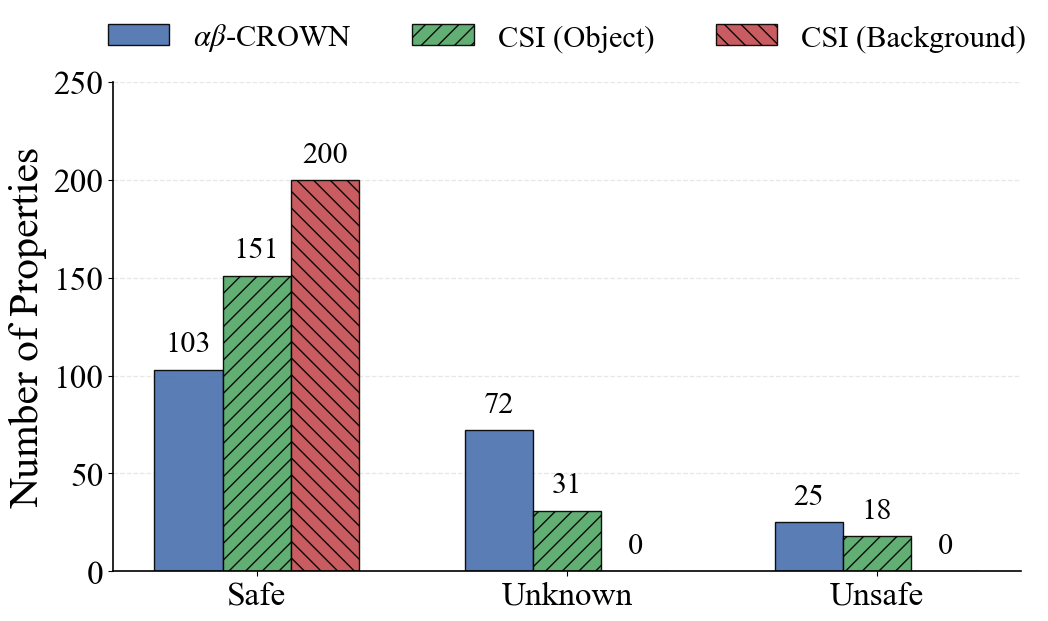

,$\alpha\beta$-CROWN,CSI (Object),CSI (Background)
Safe,103,151,200
Unknown,72,31,0
Unsafe,25,18,0


In [24]:
cifar_summary = plot_outcome_counts(
    csv_path="../../results/cifar100/cifar100_segmented.csv",
    k_value=1024,
    output_path="result_cifar.pdf",
    dataset_label="CIFAR-100",
)
cifar_summary


LaTeX was requested but the current environment cannot compile a minimal TeX document. Falling back to Matplotlib serif text.
ImageNet (k=50176)
         $\alpha\beta$-CROWN  CSI (Object)  CSI (Background)
Safe                      13            41                85
Unknown                   69            45                 1
Unsafe                    96            95                95


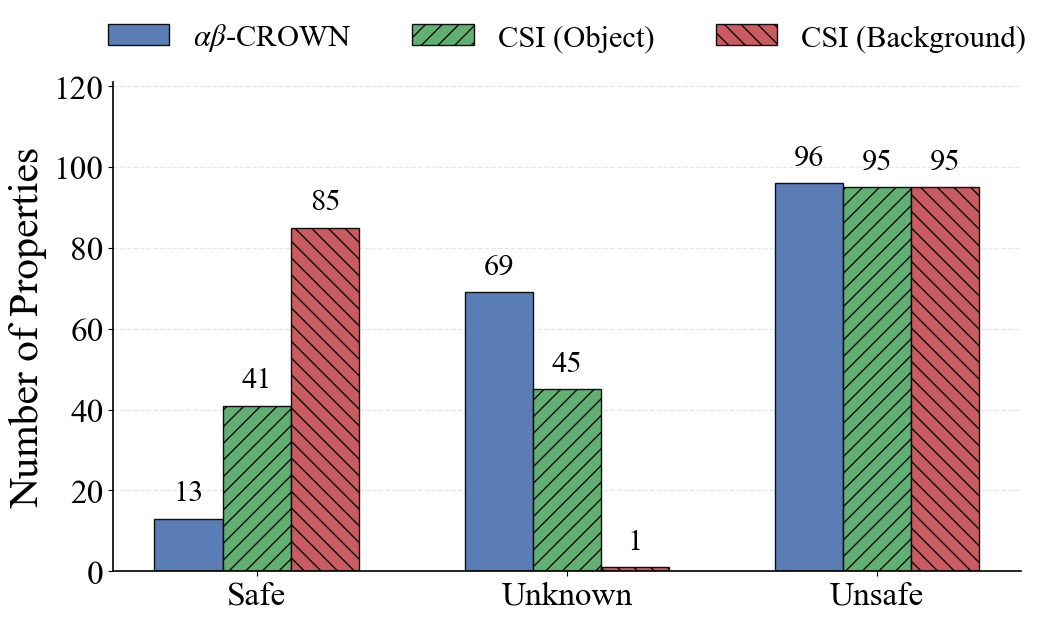

,$\alpha\beta$-CROWN,CSI (Object),CSI (Background)
Safe,13,41,85
Unknown,69,45,1
Unsafe,96,95,95


In [25]:
imagenet_summary = plot_outcome_counts(
    csv_path="../../results/vggnet16/ALL_vggnet.csv",
    k_value=50176,
    output_path="result_imagenet.pdf",
    dataset_label="ImageNet",
)
imagenet_summary
